In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("kl.csv", encoding="cp1252")

In [4]:
df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


## Step 1: Data Loading and Preparation

The FIFA 19 Complete Player Dataset was loaded and the same feature subset used in Task 2.2 was selected to ensure consistency between both tasks.

The selected attributes represent attacking ability, passing, dribbling, pace, physical strength, stamina, defensive contribution, tackling, and market value.

The **Name** column was also retained to identify the target player (Mohamed Salah), while the **Position** column will later be used for analysis and visualization.

Rows containing missing values were removed to ensure complete feature vectors for all players.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18206 non-null  float64
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18206 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

In [6]:
features = [
    "Finishing",
    "ShortPassing",
    "Dribbling",
    "SprintSpeed",
    "Strength",
    "Stamina",
    "Interceptions",
    "StandingTackle",
    "Value"
]

In [7]:
data = df[features + ["Position", "Name"]].copy()

In [8]:
data = data.dropna()

In [9]:
data.isnull().sum()

Finishing         0
ShortPassing      0
Dribbling         0
SprintSpeed       0
Strength          0
Stamina           0
Interceptions     0
StandingTackle    0
Value             0
Position          0
Name              0
dtype: int64

In [10]:
data.shape

(18147, 11)

In [11]:
def convert_value(value):
    
    if pd.isna(value):
        return np.nan

    value = value.replace("€", "")

    if value.endswith("M"):
        return float(value[:-1]) * 1_000_000

    elif value.endswith("K"):
        return float(value[:-1]) * 1_000

    else:
        return float(value)

In [12]:
data["Value"] = data["Value"].apply(convert_value)

## Step 2: Selecting the Target Player

The objective of this task is to identify players with a playing profile similar to Mohamed Salah.

The player was located in the dataset using the **Name** column, and his feature vector was extracted. This vector serves as the reference point for all subsequent similarity calculations.

All remaining players will be compared against this target vector using different similarity metrics.

In [13]:
df[df["Name"].str.contains("Salah", case=False, na=False)][["Name", "Club", "Position"]]

,Name,Club,Position
26,M. Salah,Liverpool,RM


In [14]:
target_player = data[data["Name"] == "M. Salah"]

target_player

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value,Position,Name
26,90.0,82.0,89.0,91.0,70.0,84.0,55.0,43.0,69500000.0,RM,M. Salah


In [15]:
target_player[features]

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
26,90.0,82.0,89.0,91.0,70.0,84.0,55.0,43.0,69500000.0


In [16]:
X = data[features]

X.head()

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
0,95.0,90.0,97.0,86.0,59.0,72.0,22.0,28.0,110500000.0
1,94.0,81.0,88.0,91.0,79.0,88.0,29.0,31.0,77000000.0
2,87.0,84.0,96.0,90.0,49.0,81.0,36.0,24.0,118500000.0
3,13.0,50.0,18.0,58.0,64.0,43.0,30.0,21.0,72000000.0
4,82.0,92.0,86.0,76.0,75.0,90.0,61.0,58.0,102000000.0


In [17]:
names = data["Name"]
positions = data["Position"]

## Step 4: Feature Standardization

Before computing player similarity, the selected features were standardized using **Z-score normalization**.

Since the selected attributes have different scales (for example, player market value is measured in millions, while technical skills are measured on a scale from 0 to 100), using the raw values would cause large-scale features to dominate the similarity calculations.

To ensure that every feature contributes equally, each attribute was transformed using the Z-score formula:

\[
z = \frac{x - \mu}{\sigma}
\]

where:

- **x** is the original feature value.
- **μ** is the mean of the feature.
- **σ** is the standard deviation of the feature.

Two versions of the dataset were prepared:

- **Raw Data:** Original feature values.
- **Standardized Data:** Z-score normalized values.

This allows us to compare the effect of feature scaling on the similarity search results later in the analysis.

In [18]:
target_vector_raw = target_player[features].values[0]
# mo salah
target_vector_raw

array([9.00e+01, 8.20e+01, 8.90e+01, 9.10e+01, 7.00e+01, 8.40e+01,
       5.50e+01, 4.30e+01, 6.95e+07])

In [19]:
X_raw = X.values

In [20]:
print(X_raw.shape)
print(target_vector_raw.shape)

(18147, 9)
(9,)


In [21]:
mean = X.mean()
std = X.std()

X_standardized = (X - mean) / std

In [22]:
X_standardized.describe().round(2)

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
count,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00
mean,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.23,-3.52,-2.72,-3.60,-3.85,-3.22,-2.11,-2.11,-0.43
25%,-0.80,-0.32,-0.34,-0.53,-0.58,-0.45,-1.00,-0.96,-0.38
50%,0.18,0.22,0.30,0.16,0.13,0.17,0.26,0.34,-0.31
75%,0.84,0.63,0.67,0.70,0.69,0.68,0.84,0.84,-0.07
max,2.53,2.33,2.20,2.13,2.52,2.06,2.19,2.09,20.72


In [23]:
target_index = target_player.index[0]

In [24]:
target_vector_std = X_standardized.loc[target_index].values

In [25]:
X_std = X_standardized.values

In [26]:
print(X_std.shape)
print(target_vector_std.shape)

(18147, 9)
(9,)


## Step 4: 
## Euclidean Distance

Euclidean Distance measures the straight-line distance between two feature vectors.

Players with smaller distances are considered more similar to the target player.

Since this metric depends on the magnitude of feature values, it is expected to be strongly influenced by large-scale features such as player market value when applied to raw (unstandardized) data.

In [27]:
def euclidean_distance(X, target):
    distances = np.sqrt(np.sum((X - target) ** 2, axis=1))
    return distances

In [28]:
euclidean_raw = euclidean_distance(
    X_raw,
    target_vector_raw
)

In [29]:
euclidean_raw[:5]

array([41000000.00002143,  7500000.00006233, 49000000.0000126 ,
        2500000.0031818 , 32500000.00001108])

In [30]:
sorted_indices = np.argsort(euclidean_raw)

In [31]:
# عشان نستبعد صلاح نفسه
top5_indices = sorted_indices[1:6]

In [32]:
data.iloc[top5_indices][["Name", "Position", "Value"]]

,Name,Position,Value
32,Coutinho,LW,69500000.0
28,J. Rodríguez,LAM,69500000.0
9,J. Oblak,GK,68000000.0
6,L. Modri?,RCM,67000000.0
3,De Gea,GK,72000000.0


### Observation

The results obtained using the raw feature values are not meaningful in terms of playing style.

The returned players mainly have market values close to Mohamed Salah rather than similar technical or physical attributes. For example, two goalkeepers appear in the top five despite having completely different playing roles.

This happens because **player market value** is measured on a much larger numerical scale than the remaining features. As a result, the Euclidean distance becomes dominated by the Value feature, while differences in football skills contribute very little.

In [33]:
# on standared
euclidean_std = euclidean_distance(
    X_std,
    target_vector_std
)

In [34]:
sorted_indices_std = np.argsort(euclidean_std)

In [35]:
top5_indices_std = sorted_indices_std[1:6]

In [36]:
euclidean_std_results = data.iloc[top5_indices_std][
    ["Name", "Position", "Value"]
].copy()

euclidean_std_results["Distance"] = euclidean_std[top5_indices_std]

euclidean_std_results

,Name,Position,Value,Distance
32,Coutinho,LW,69500000.0,1.625595
17,A. Griezmann,CAM,78000000.0,1.963329
28,J. Rodríguez,LAM,69500000.0,1.973016
55,L. Sané,LW,61000000.0,2.015221
1,Cristiano Ronaldo,ST,77000000.0,2.074489


### Observation

After standardization, the similarity results become much more meaningful.

The nearest players are now attacking players with playing styles closer to Mohamed Salah, such as Coutinho, Griezmann, Sané, and Cristiano Ronaldo. Unlike the raw data experiment, no goalkeepers appear in the top results.

This confirms that standardization prevents the **Value** feature from dominating the distance calculation and allows all player attributes to contribute equally when measuring similarity.

##  Manhattan Distance

Manhattan Distance measures the total absolute difference between two feature vectors.

Unlike Euclidean Distance, it does not square the feature differences. Instead, it sums the absolute differences across all attributes.

As with Euclidean Distance, the metric was evaluated on both the raw and standardized datasets to examine the impact of feature scaling on the similarity results.

In [37]:
def manhattan_distance(X, target):
    distances = np.sum(np.abs(X - target), axis=1)
    return distances

In [38]:
manhattan_raw = manhattan_distance(
    X_raw,
    target_vector_raw
)

In [39]:
sorted_indices_raw = np.argsort(manhattan_raw)

In [40]:
top5_indices_raw = sorted_indices_raw[1:6]

In [41]:
manhattan_raw_results = data.iloc[top5_indices_raw][
    ["Name", "Position", "Value"]
].copy()

manhattan_raw_results["Distance"] = manhattan_raw[top5_indices_raw]

manhattan_raw_results

,Name,Position,Value,Distance
28,J. Rodríguez,LAM,69500000.0,60.0
32,Coutinho,LW,69500000.0,66.0
9,J. Oblak,GK,68000000.0,1500358.0
6,L. Modri?,RCM,67000000.0,2500127.0
3,De Gea,GK,72000000.0,2500307.0


### Observation

The Manhattan Distance on the raw data is also heavily dominated by the **Value** feature.

Players with market values identical or very close to Mohamed Salah appear first, while players with even small differences in market value receive extremely large distances measured in millions.

This demonstrates that Manhattan Distance, like Euclidean Distance, is highly sensitive to differences in feature scales when the data is not standardized.

In [42]:
manhattan_std = manhattan_distance(
    X_std,
    target_vector_std
)

In [43]:
sorted_indices_std = np.argsort(manhattan_std)

top5_indices_std = sorted_indices_std[1:6]

In [44]:
manhattan_std_results = data.iloc[top5_indices_std][
    ["Name", "Position", "Value"]
].copy()

manhattan_std_results["Distance"] = manhattan_std[top5_indices_std]

manhattan_std_results

,Name,Position,Value,Distance
28,J. Rodríguez,LAM,69500000.0,3.816673
17,A. Griezmann,CAM,78000000.0,3.898694
25,K. Mbappé,RM,81000000.0,3.928459
32,Coutinho,LW,69500000.0,3.998532
55,L. Sané,LW,61000000.0,4.413166


### Observation

After standardization, the Manhattan Distance returns a much more realistic shortlist.

The retrieved players are all attacking players with similar technical and physical profiles to Mohamed Salah, including J. Rodríguez, Griezmann, Mbappé, Coutinho, and Sané.

Compared to the raw data, the standardized results are significantly more meaningful because all features contribute equally to the distance calculation instead of being dominated by player market value.

##  Cosine Similarity

Cosine Similarity measures how similar two players are based on the direction of their feature vectors rather than the absolute distance between them.

Unlike Euclidean and Manhattan distances, Cosine Similarity focuses on the overall pattern of player attributes, making it useful for identifying players with similar playing profiles even if their feature magnitudes differ.

The metric was applied to both the raw and standardized datasets to evaluate the effect of feature scaling on the similarity search.

In [45]:
def cosine_similarity(X, target):
    dot_product = np.sum(X * target, axis=1)

    X_norm = np.sqrt(np.sum(X**2, axis=1))
    target_norm = np.sqrt(np.sum(target**2))

    similarity = dot_product / (X_norm * target_norm)

    return similarity

In [46]:
cosine_raw = cosine_similarity(
    X_raw,
    target_vector_raw
)

In [47]:
sorted_indices_raw = np.argsort(cosine_raw)[::-1]

In [48]:
top5_indices_raw = sorted_indices_raw[1:6]

In [49]:
cosine_raw_results = data.iloc[top5_indices_raw][
    ["Name", "Position", "Value"]
].copy()

cosine_raw_results["Similarity"] = cosine_raw[top5_indices_raw]

cosine_raw_results

,Name,Position,Value,Similarity
32,Coutinho,LW,69500000.0,1.0
28,J. Rodríguez,LAM,69500000.0,1.0
55,L. Sané,LW,61000000.0,1.0
56,Bernardo Silva,RW,59500000.0,1.0
31,C. Eriksen,CAM,73500000.0,1.0


### Observation

The similarity scores obtained from the raw data are extremely close to 1 because the **Value** feature has a much larger numerical scale than the remaining attributes.

As a result, the market value dominates the direction of the player vectors, causing many players with similar values to appear almost identical according to Cosine Similarity.

After standardization, the similarity scores become more meaningful because every feature contributes equally to the vector direction.

In [50]:
cosine_std = cosine_similarity(
    X_std,
    target_vector_std
)

In [51]:
sorted_indices_std = np.argsort(cosine_std)[::-1]

top5_indices_std = sorted_indices_std[1:6]

In [52]:
cosine_std_results = data.iloc[top5_indices_std][
    ["Name", "Position", "Value"]
].copy()

cosine_std_results["Similarity"] = cosine_std[top5_indices_std]

cosine_std_results

,Name,Position,Value,Similarity
25,K. Mbappé,RM,81000000.0,0.996827
79,Marco Asensio,RW,54000000.0,0.995267
17,A. Griezmann,CAM,78000000.0,0.994631
5,E. Hazard,LF,93000000.0,0.993908
55,L. Sané,LW,61000000.0,0.993447


### Observation

The standardized Cosine Similarity produced a realistic shortlist of attacking players, including Mbappé, Marco Asensio, Griezmann, Hazard, and Sané.

Unlike distance-based metrics, Cosine Similarity compares the direction of the feature vectors rather than their absolute magnitudes. This makes it more suitable for identifying players with similar playing profiles even when their overall attribute values differ.

The raw Cosine results were much less informative because the very large market value feature caused many player vectors to point in similar directions, producing similarity scores extremely close to 1.

##  Comparing the Similarity Metrics

In [53]:
comparison = pd.DataFrame({
    "Euclidean": euclidean_std_results["Name"].values,
    "Manhattan": manhattan_std_results["Name"].values,
    "Cosine": cosine_std_results["Name"].values
})

comparison

,Euclidean,Manhattan,Cosine
0,Coutinho,J. Rodríguez,K. Mbappé
1,A. Griezmann,A. Griezmann,Marco Asensio
2,J. Rodríguez,K. Mbappé,A. Griezmann
3,L. Sané,Coutinho,E. Hazard
4,Cristiano Ronaldo,L. Sané,L. Sané




The three similarity metrics produce similar but not identical shortlists.

- **Euclidean Distance** measures the straight-line distance between feature vectors.
- **Manhattan Distance** measures the total absolute difference across all features.
- **Cosine Similarity** compares the direction of feature vectors, focusing on the overall attribute profile rather than absolute values.

Two players, **Antoine Griezmann** and **Leroy Sané**, appear in the top five for all three metrics, making them the most consistent matches to Mohamed Salah.

**Coutinho** and **James Rodríguez** appear in both Euclidean and Manhattan results because their overall feature values are numerically close to Salah's.

**Kylian Mbappé**, **Marco Asensio**, and **Eden Hazard** are highlighted by Cosine Similarity because this metric emphasizes similarity in playing style and attribute patterns rather than absolute feature distances.

## Final Recommendation

Based on the agreement between the three similarity metrics, the final recommended shortlist is:

1. Antoine Griezmann
2. Leroy Sané
3. Philippe Coutinho
4. James Rodríguez
5. Kylian Mbappé

These players consistently appear across multiple similarity metrics, indicating that they share technical and physical characteristics with Mohamed Salah. Their profiles include strong dribbling ability, finishing, pace, passing quality, and attacking play, making them the most suitable data-driven recommendations.

## PCA Visualization

To validate the similarity search, the players are projected onto the first two principal components using the custom PCA implementation developed in Task 2.2.

All players are plotted in grey, while Mohamed Salah and the final recommended shortlist are highlighted. This visualization helps verify whether the recommended players are located close to Salah in the reduced feature space.

In [54]:
pca_df = pd.read_csv("pca_projection.csv")

In [55]:
pca_df["Name"] = data["Name"].values

In [59]:
highlight_indices = [26, 17, 55, 32, 28, 25]

selected = pca_df.loc[highlight_indices]

In [60]:
print(selected)

         PC1       PC2          Name
26  5.555351  2.295906      M. Salah
17  5.357317  2.893031  A. Griezmann
55  4.550772  2.890028       L. Sané
32  5.078307  1.977229      Coutinho
28  4.582981  1.799040  J. Rodríguez
25  5.628917  3.068541     K. Mbappé


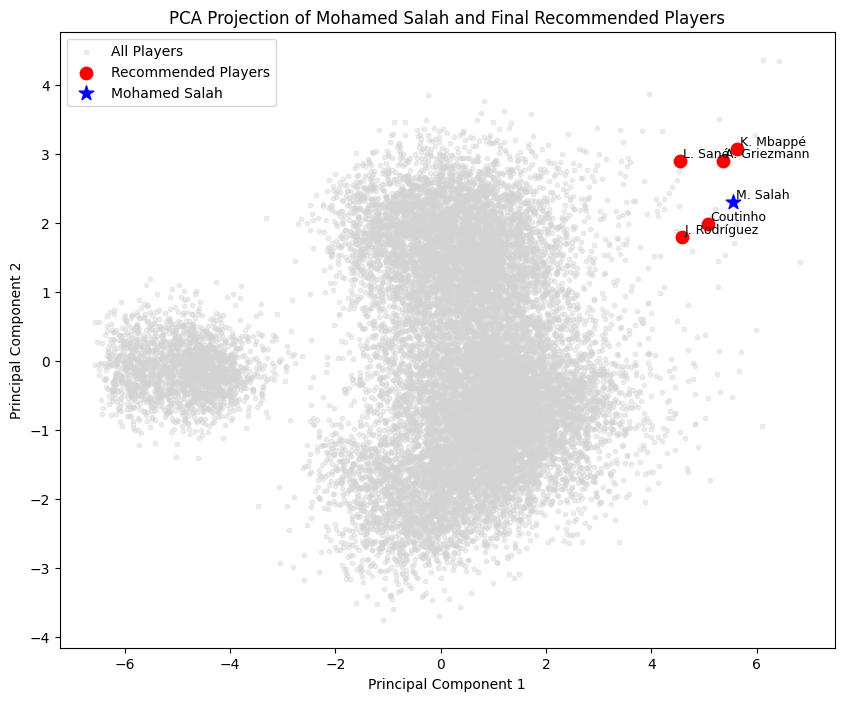

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# جميع اللاعبين
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    color="lightgray",
    alpha=0.4,
    s=10,
    label="All Players"
)

# All shortlisted players
others = selected[selected["Name"] != "M. Salah"]

plt.scatter(
    others["PC1"],
    others["PC2"],
    color="red",
    s=80,
    label="Recommended Players"
)

# Mohamed Salah
salah = selected[selected["Name"] == "M. Salah"]

plt.scatter(
    salah["PC1"],
    salah["PC2"],
    color="blue",
    s=120,
    marker="*",
    label="Mohamed Salah"
)

# كتابة الأسماء
for _, row in selected.iterrows():
    plt.text(
        row["PC1"] + 0.05,
        row["PC2"] + 0.05,
        row["Name"],
        fontsize=9
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mohamed Salah and Final Recommended Players")
plt.legend()

plt.show()

### Discussion

The PCA visualization confirms the effectiveness of the similarity search.

Mohamed Salah and the recommended players are located within the same general region of the PCA space. Coutinho and James Rodríguez appear closest to Salah, while Kylian Mbappé, Antoine Griezmann, and Leroy Sané are also positioned nearby within the same cluster.

Although PCA reduces the original nine-dimensional feature space into only two principal components, the recommended players remain close to the target player. This visual validation supports the results obtained from the Euclidean, Manhattan, and Cosine similarity metrics and increases confidence in the final scouting recommendation.